# Statistical Mechanics of Market Microstructure
**Author:** Esteban Cardenas | **Degree:** MSc Physics of Data

This notebook demonstrates a production-ready quantitative finance pipeline. It ingests high-frequency tick data (millions of rows), optimizes memory via downcasting, and applies statistical physics principles to challenge classical time-series assumptions. 

We will prove that parameterizing market data by economic energy (Dollar Bars) recovers Gaussian normality, filter out microscopic thermal jitter (Bid-Ask bounce), and deploy a Ridge Regression model to predict short-term kinematics using Order Flow Imbalance (OFI).


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) # Move up one directory to access 'src'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import acf

from src.tick_wrangler import HighFreqTickWrangler
from src.microstructure import (
    create_time_bars,
    create_volume_bars,
    create_dollar_bars,
    matching_time_freq,
    analyze_bar_normality,
    calculate_volatility_signature,
    find_noise_cutoff
)
from src.modeling import predictive_ofi_modeling

%matplotlib inline

## Phase 1: Data Ingestion & Memory Optimization
We instantiate the `HighFreqTickWrangler` to download raw tick data from Binance (SHA256-verified and cached in `data/`), infer the timestamp unit from its magnitude (Binance moved from milliseconds to microseconds in 2025), and trim Pandas memory by storing quantities as `float32`. Prices stay `float64` (float32 would corrupt quotes such as 87648.22 → 87648.21875), and every cumulative sum runs in `float64` to avoid drift.

In [2]:
# Initialize for Bitcoin (January 1st, 2026 - or change to any date)
wrangler = HighFreqTickWrangler(symbol="BTCUSDT", date="2026-01-01")

# Execute Pipeline
if not wrangler.download_binance_trades():
    raise RuntimeError("Download failed - check the symbol/date and your connection.")
wrangler.load_and_optimize()
wrangler.engineer_features()

# Display a preview of the clean, vectorized data
wrangler.df.head()

Archive already cached at /home/ubuntu/High-Frequency-Tick-Data-Wrangler-A-Statistical-Mechanics-Approach-to-Market-Microstructure/data/BTCUSDT-trades-2026-01-01.zip.
Loading data into memory...


Loaded 1,449,281 rows (timestamps in 'us'). Memory usage: 29.02 MB
Engineering features using vectorized operations...
Feature engineering completed in 0.0999 seconds.


,price,qty,is_buyer_maker,trade_direction,signed_volume,cvd,rolling_vwap
timestamp,,,,,,,
2026-01-01 00:00:00.039409,87648.21,0.08185,True,-1,-0.08185,-0.08185,87648.210000
2026-01-01 00:00:00.272386,87648.22,0.00013,False,1,0.00013,-0.08172,87648.210016
2026-01-01 00:00:00.276733,87648.22,0.00023,False,1,0.00023,-0.08149,87648.210044
2026-01-01 00:00:00.396949,87648.22,0.01032,False,1,0.01032,-0.07117,87648.211154
2026-01-01 00:00:00.401005,87648.22,0.00206,False,1,0.00206,-0.06911,87648.211347


## Phase 2: Event-Based Resampling & Gaussian Recovery
Classical finance samples by physical time ($dt$), leading to heteroskedasticity and fat tails (extreme risk). By sampling based on economic throughput (Dollar Bars), we parameterize the system by its "arc length," absorbing volatility bursts.

Coarser bars look more Gaussian simply by aggregation (Central Limit Theorem), so for a fair test we also build time bars at the **same resolution** as the dollar bars (same number of bars over the day).

In [3]:
# Generate the bar schemas
time_bars = create_time_bars(wrangler.df, freq='1min')
vol_bars = create_volume_bars(wrangler.df, volume_target=50)          # 50 BTC
dollar_bars = create_dollar_bars(wrangler.df, dollar_target=2_500_000) # $2.5M

# Resolution-matched control: time bars with the same bar count as the dollar bars
matched_freq = matching_time_freq(wrangler.df, n_bars=len(dollar_bars))
matched_time_bars = create_time_bars(wrangler.df, freq=matched_freq)

# Run statistical evaluation (Jarque-Bera, Kurtosis, Skewness)
normality_results = analyze_bar_normality({
    "Time Bars (1min)": time_bars,
    f"Time Bars ({matched_freq}, matched)": matched_time_bars,
    "Volume Bars (50 BTC)": vol_bars,
    "Dollar Bars ($2.5M)": dollar_bars,
})
normality_results.style.format({
    "Mean Return": "{:.2e}", "Std Dev": "{:.2e}", "Skewness": "{:.3f}",
    "Excess Kurtosis": "{:.2f}", "Jarque-Bera Stat": "{:.2f}", "p-value": "{:.2e}"
})

Sampling Time Bars (1min)...
Sampling Volume Bars (Target: 50 units)...


Sampling Dollar Bars (Target: $2,500,000)...


Sampling Time Bars (391s)...


,Total Bars,Mean Return,Std Dev,Skewness,Excess Kurtosis,Jarque-Bera Stat,p-value
Bar Schema,,,,,,,
Time Bars (1min),1439,9.38e-06,2.31e-04,0.695,11.03,7405.05,0.00e+00
"Time Bars (391s, matched)",220,5.68e-05,5.46e-04,0.551,1.57,33.65,4.92e-08
Volume Bars (50 BTC),125,9.74e-05,8.01e-04,0.173,0.17,0.77,6.79e-01
Dollar Bars ($2.5M),221,5.43e-05,6.33e-04,0.212,0.07,1.70,4.27e-01


## Phase 3: Visualizing Market Dynamics
We plot the probability density functions (PDF) of the resolution-matched time bars and the dollar bars against a fitted Gaussian, and measure volatility clustering via the Autocorrelation Function (ACF) of squared returns.

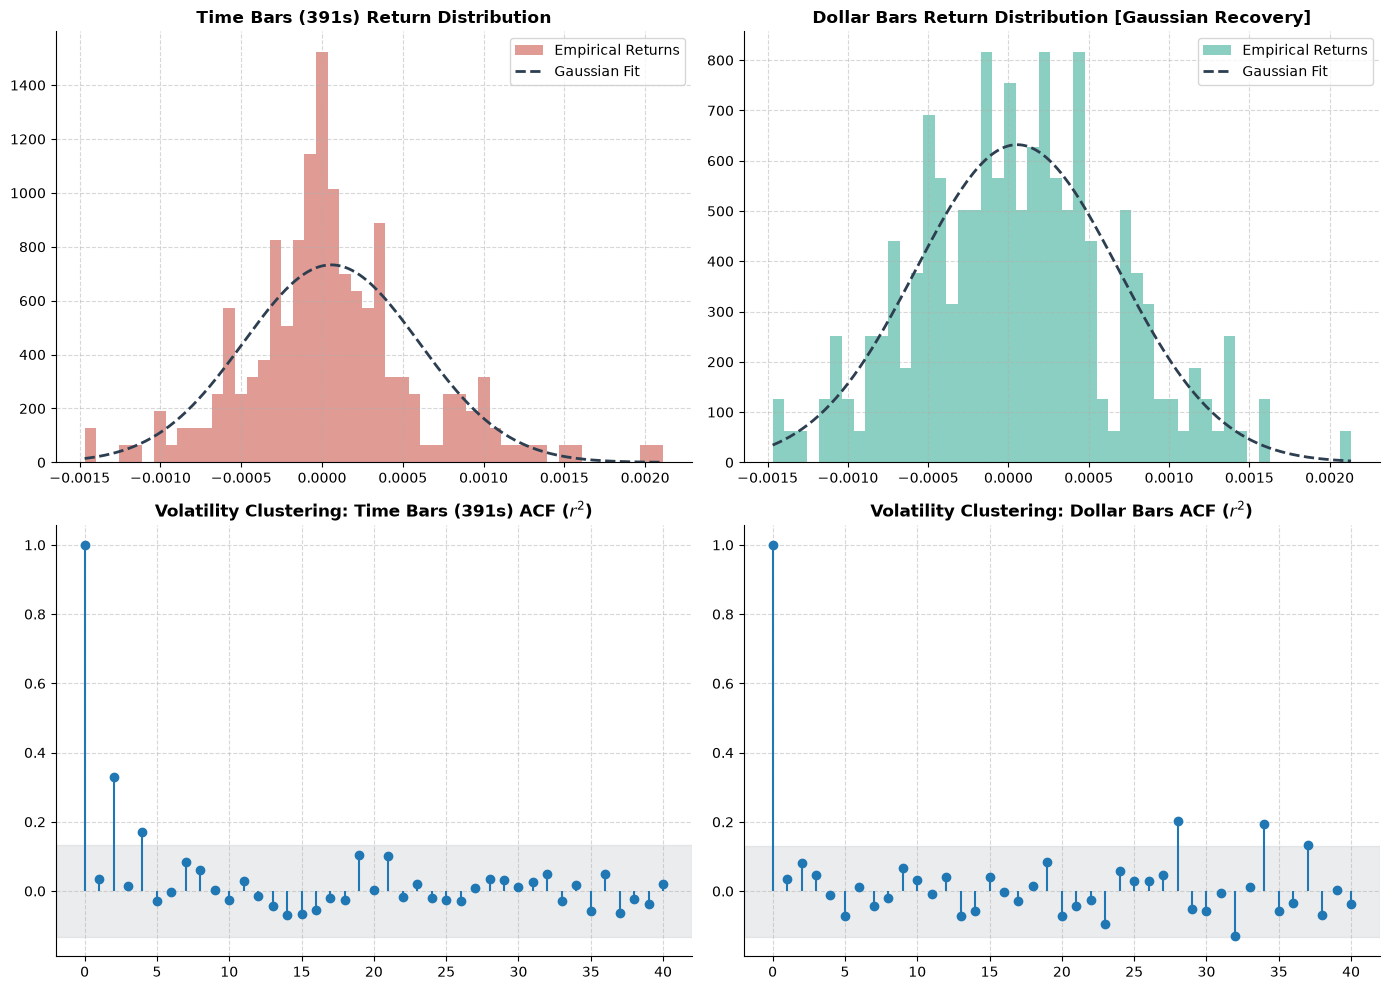

In [4]:
def visualize_microstructure_matplotlib(time_bars, dollar_bars, time_label='Time Bars'):
    r_time = time_bars['log_return'].dropna().values
    r_dollar = dollar_bars['log_return'].dropna().values

    COLOR_TIME, COLOR_DOLLAR, COLOR_GAUSS = '#C0392B', '#16A085', '#2C3E50'
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
    fig.patch.set_facecolor('white')

    for ax in axes.flat:
        ax.set_facecolor('white')
        ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # TIME BARS PDF
    axes[0, 0].hist(r_time, bins=50, density=True, color=COLOR_TIME, alpha=0.5, label='Empirical Returns')
    mu_t, std_t = stats.norm.fit(r_time)
    x_t = np.linspace(np.min(r_time), np.max(r_time), 200)
    axes[0, 0].plot(x_t, stats.norm.pdf(x_t, mu_t, std_t), color=COLOR_GAUSS, linestyle='--', lw=2, label='Gaussian Fit')
    axes[0, 0].set_title(f'{time_label} Return Distribution', fontweight='bold')
    axes[0, 0].legend()

    # DOLLAR BARS PDF
    axes[0, 1].hist(r_dollar, bins=50, density=True, color=COLOR_DOLLAR, alpha=0.5, label='Empirical Returns')
    mu_d, std_d = stats.norm.fit(r_dollar)
    x_d = np.linspace(np.min(r_dollar), np.max(r_dollar), 200)
    axes[0, 1].plot(x_d, stats.norm.pdf(x_d, mu_d, std_d), color=COLOR_GAUSS, linestyle='--', lw=2, label='Gaussian Fit')
    axes[0, 1].set_title('Dollar Bars Return Distribution [Gaussian Recovery]', fontweight='bold')
    axes[0, 1].legend()

    # AUTOCORRELATION
    lags = 40
    lag_arr = np.arange(lags + 1)
    
    # Time ACF
    acf_time = acf(r_time**2, nlags=lags, fft=True)
    conf_time = 1.96 / np.sqrt(len(r_time))
    axes[1, 0].stem(lag_arr, acf_time, markerfmt='o', basefmt=" ")
    axes[1, 0].axhspan(-conf_time, conf_time, color='#BDC3C7', alpha=0.3)
    axes[1, 0].set_title(f'Volatility Clustering: {time_label} ACF ($r^2$)', fontweight='bold')

    # Dollar ACF
    acf_dollar = acf(r_dollar**2, nlags=lags, fft=True)
    conf_dollar = 1.96 / np.sqrt(len(r_dollar))
    axes[1, 1].stem(lag_arr, acf_dollar, markerfmt='o', basefmt=" ")
    axes[1, 1].axhspan(-conf_dollar, conf_dollar, color='#BDC3C7', alpha=0.3)
    axes[1, 1].set_title('Volatility Clustering: Dollar Bars ACF ($r^2$)', fontweight='bold')

    plt.tight_layout()
    plt.show()

visualize_microstructure_matplotlib(matched_time_bars, dollar_bars, time_label=f'Time Bars ({matched_freq})')

## Phase 4: Filtering Microstructure Noise
At ultra-high frequencies, realized volatility (RV) is biased by market microstructure. Bid-ask bounce (negatively autocorrelated tick returns) inflates RV, while stale prices and order splitting (positively autocorrelated tick returns) deflate it. The Volatility Signature Plot shows RV versus sampling frequency; `find_noise_cutoff` locates the first frequency from which RV stays within 10% of the low-frequency plateau, i.e., where the latent volatility is recovered.

For BTCUSDT the curve **rises** toward the plateau: with a $0.01 tick on an ~$87k asset, bid-ask bounce is negligible and the dominant high-frequency distortion is positive autocorrelation from stale prices and split orders.

Calculating Realized Volatility across frequencies...


Optimal sampling frequency: 5 Min


,Freq_Code,Label,N_Returns,Annualized_RV
0,1s,1 Sec,74959,0.126211
1,5s,5 Sec,17275,0.138368
2,15s,15 Sec,5759,0.150020
3,30s,30 Sec,2879,0.159480
4,1min,1 Min,1439,0.167464
5,2min,2 Min,719,0.169679
6,5min,5 Min,287,0.152097
7,10min,10 Min,143,0.154980
8,15min,15 Min,95,0.148620
9,30min,30 Min,47,0.139207


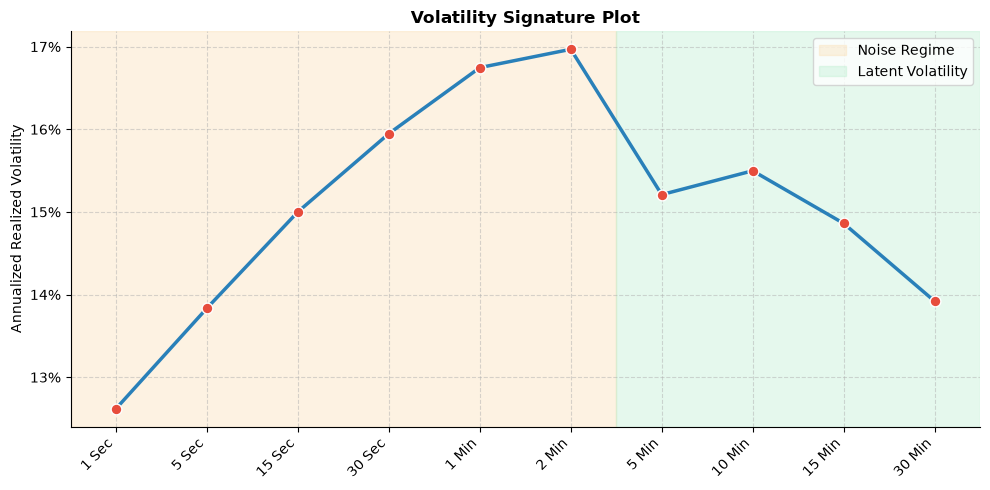

In [5]:
def plot_signature_curve(rv_df, cutoff_idx):
    fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    x_pos = np.arange(len(rv_df))
    y_vals = rv_df['Annualized_RV'].values

    ax.plot(x_pos, y_vals, color='#2980B9', linewidth=2.5, zorder=3)
    ax.scatter(x_pos, y_vals, color='#E74C3C', s=60, zorder=4, edgecolor='white')

    boundary = cutoff_idx - 0.5
    ax.axvspan(-0.5, boundary, color='#FAD7A1', alpha=0.3, zorder=1, label='Noise Regime')
    ax.axvspan(boundary, len(rv_df) - 0.5, color='#ABEBC6', alpha=0.3, zorder=1, label='Latent Volatility')
    ax.set_xlim(-0.5, len(rv_df) - 0.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(rv_df['Label'], rotation=45, ha='right')
    ax.set_ylabel('Annualized Realized Volatility')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title('Volatility Signature Plot', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Calculate, locate the noise cutoff and plot
rv_df = calculate_volatility_signature(wrangler.df)
cutoff_idx = find_noise_cutoff(rv_df, tolerance=0.10)
print(f"Optimal sampling frequency: {rv_df['Label'].iloc[cutoff_idx]}")
display(rv_df)
plot_signature_curve(rv_df, cutoff_idx)

## Phase 5: Predictive Kinematics (Order Flow Imbalance)
We apply a Ridge Regression model to test whether net market force (Order Flow Imbalance) over one 10-second interval predicts the return of the **next** interval. The target is shifted to $t+1$, the split is chronological (first 80% train, last 20% test), and outlier-trimming thresholds are learned on the training set only, so no test information leaks into fitting.

Resampling data to 10s intervals for predictive modeling...
Model Training Complete.
Train / Test samples: 6770 / 1681
R-Squared (Out of Sample): 0.0041
Directional Hit Rate (Out of Sample, non-zero returns): 56.07%


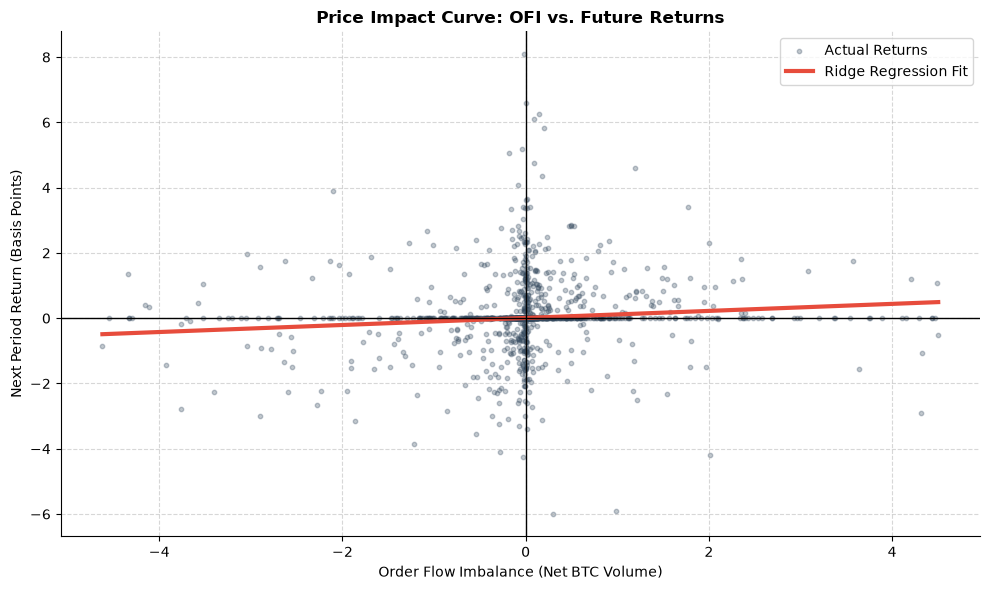

In [6]:
def plot_price_impact_curve(X_test, y_test, y_pred):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.scatter(X_test, y_test, alpha=0.3, color='#34495E', s=10, label='Actual Returns')
    order = np.argsort(X_test.ravel())
    ax.plot(X_test.ravel()[order], y_pred[order], color='#E74C3C', linewidth=3, label='Ridge Regression Fit')
    
    ax.axhline(0, color='black', linewidth=1, zorder=2)
    ax.axvline(0, color='black', linewidth=1, zorder=2)
    
    ax.set_title('Price Impact Curve: OFI vs. Future Returns', fontweight='bold')
    ax.set_xlabel('Order Flow Imbalance (Net BTC Volume)')
    ax.set_ylabel('Next Period Return (Basis Points)')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Execute predictive modeling
clean_bars, model, X_test, y_test, y_pred = predictive_ofi_modeling(wrangler.df, freq='10s')

# Plot the impact curve
plot_price_impact_curve(X_test, y_test, y_pred)